Computing p-values from variable importance (Regression)
=====================================

This is an *VariantSpark* example notebook.


One of the main applications of VariantSpark is discovery of genomic variants correlated with a response variable using random forest importance.

The `chr22_1000.vcf` is a very small sample of the chromosome 22 VCF file from the 1000 Genomes Project.

`chr22-values.csv` contains a continuous response variable constructed as a weighted linear combination of two genomic variants:

$$\text{response} = 0.4 \times \texttt{22\_16051347\_G\_C} + (-0.6) \times \texttt{22\_16050984\_A\_G}$$

We would therefore expect these two positions to rank as the most important variables in the analysis.

Both data sets are located in the `..\data` directory.

This notebook demonstrates how to correctly get the p-values for each of the SNPs and their significant ones based on a *VariantSpark* regression model.

> **Caveat:** RFLocalFDR (Dunne et al.) was designed and validated for Gini-based MDI from classification random forests. Its application here to variance-reduction MDI from a regression random forest is an **unvalidated assumption**. The null distribution empirically fits a skew-normal on this dataset, but no theoretical justification exists that the method's assumptions hold for regression MDI. Results should be interpreted with appropriate caution.

Step 1: Import VariantSpark and Matplotlib. Create a spark session with VariantSpark jar attached

In [1]:
import varspark as vs
from pyspark.sql import SparkSession
spark = vs.configure_spark(
    SparkSession.builder.config('spark.jars', vs.find_jar())
).getOrCreate()
from matplotlib import pyplot as plt

26/04/16 16:24:18 WARN Utils: Your hostname, RADON-BH resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/04/16 16:24:18 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
26/04/16 16:24:19 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Step 2: Create a `VarsparkContext` using `SparkSession` object (here injected as `spark`):

In [2]:
vc = vs.VarsparkContext(spark, silent=True)

Step 3: Load genotypes from a sample `.vcf` file.

In [3]:
genotypes = vc.import_vcf('../../data/chr22_1000.vcf')

../../data/chr22_1000.vcf is loading to spark RDD, isBGZFile: false


Step 4: Load the continuous response variable from `chr22-values.csv`.

In [4]:
values = vc.load_response('../../data/chr22-values.csv', col_name='response')

Step 5: Build the random forest model with `response` as the response variable.

In [5]:
rf_model = vs.RandomForestRegressor(vc, mtry_fraction=0.20, min_node_size =5, max_depth=10, seed=13)
rf_model.fit_trees(genotypes, values, n_trees=300, batch_size=50)

Step 6: Display the results: print OOB error calculated variable importance.

In [6]:
import pandas as pd
print("OOB error: %s" % rf_model.oob_error())
ia = rf_model.importance_analysis()
ia.variable_importance().sort_values(by='importance', ascending=False).head(10)

OOB error: 0.13896073759132826


,variant_id,importance,splitCount
253,22_16051347_G_C,398.928138,629
969,22_16051497_A_G,331.760100,592
975,22_16053791_C_A,111.134859,217
1229,22_16052239_A_G,49.245692,149
1343,22_16052513_G_C,33.199445,93
1669,22_16053862_C_T,20.364038,105
1,22_16052618_G_A,18.701701,58
1113,22_16051453_A_C,17.801071,105
1345,22_16054667_C_G,17.460169,52
384,22_16051249_T_C,15.739508,93


Step 7: Get the fdr calculation class from the VariantSpark model

In [7]:
fdrCalc = rf_model.get_lfdr()

Step 8: Visualize the distribution of importances based on the number of splits for a variable to be included. These distributions can take many shapes but the goal here is that there is one big *unimodal distribution*. In this case, setting the threshold to `2` looks the best.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


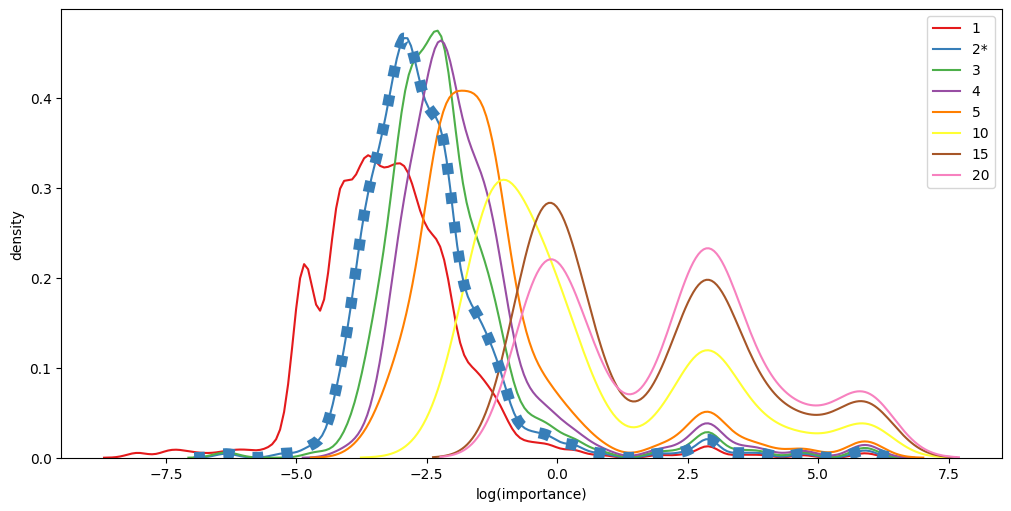

In [8]:
fig, ax1 = plt.subplots(figsize=(10, 5), layout='constrained')
fdrCalc.plot_log_densities(ax1, cutoff_list=[1, 2, 3, 4, 5, 10, 15, 20], find_automatic_best=True)
plt.show()

Step 9: This is a sanity check to visualize the splitcount was correct and consistent. (optional)

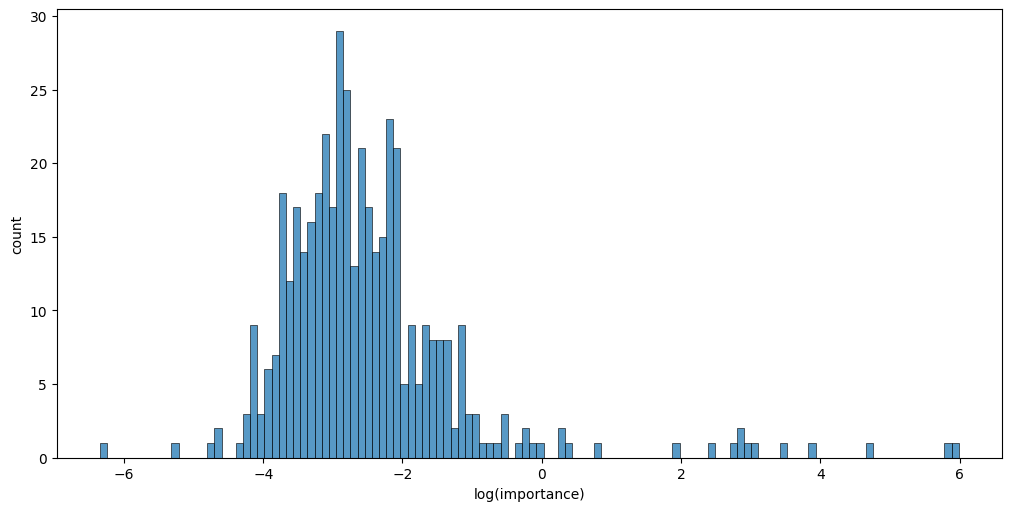

In [9]:
fig, ax2 = plt.subplots(figsize=(10, 5), layout='constrained')
fdrCalc.plot_log_hist(ax2, split_count=2)
plt.show()

Step 10: Compute the p-values, their significance, and the expected false discovery rate (FDR).

In [10]:
pvalsDF, fdr = fdrCalc.compute_fdr(countThreshold = 2, local_fdr_cutoff = 0.05)
pvalsDF, fdr

(          variant_id  logImportance        pvalue  is_significant
 0    22_16053746_A_T      -6.346695  1.000000e+00           False
 1    22_17773884_C_T      -5.253097  9.999117e-01           False
 2    22_17744553_T_C      -4.791557  9.984920e-01           False
 3    22_17735894_G_A      -4.638680  9.966578e-01           False
 4    22_17730130_G_A      -4.603455  9.960246e-01           False
 ..               ...            ...           ...             ...
 437  22_16052513_G_C       3.502533  8.183511e-08            True
 438  22_16052239_A_G       3.896822  1.512448e-08            True
 439  22_16053791_C_A       4.710744  3.531015e-10            True
 440  22_16051497_A_G       5.804412  1.269318e-12            True
 441  22_16051347_G_C       5.988781  4.599654e-13            True
 
 [442 rows x 4 columns],
 0.001525878649961084)

Step 11: Visualize that the distribution (purple bars), fits the fitted distribution (red line). The "C" (orange) should fall on the right of the red distribution. And the local fdr (blue) crossing the black line (cutoff threshold) is on the right from 'C'. (optional but encouraged)

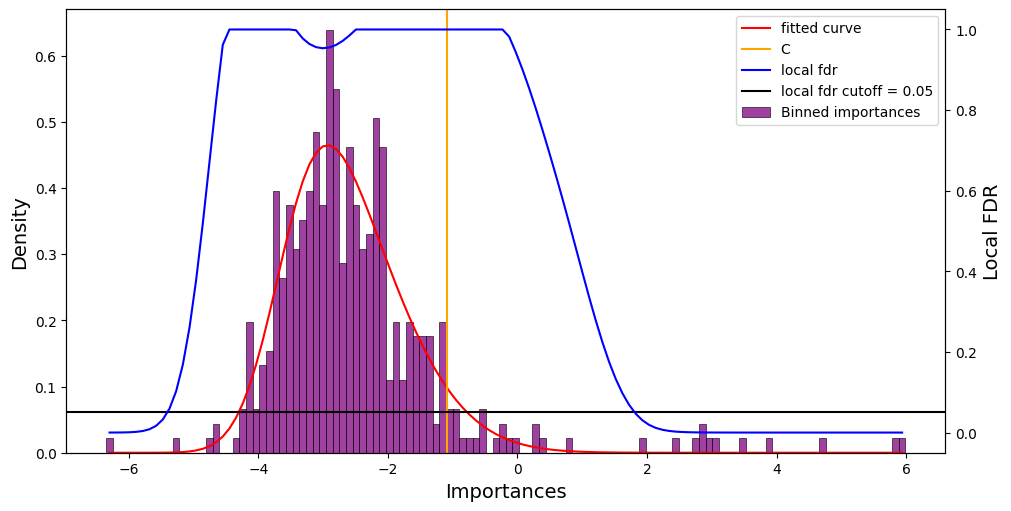

In [11]:
fig, ax3 = plt.subplots(figsize=(10, 5), layout='constrained')
fdrCalc.plot(ax3)
plt.show()